<a href="https://colab.research.google.com/github/amanilayouni/Amani_Karam_Ryma_arene_ml/blob/main/Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
!git clone https://github.com/amanilayouni/Amani_Karam_Ryma_arene_ml.git
!git branch

fatal: destination path 'Amani_Karam_Ryma_arene_ml' already exists and is not an empty directory.
fatal: not a git repository (or any of the parent directories): .git


In [78]:
# Cellule 1 — Installation des dépendances

!pip install nltk scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Installation terminée !")

Installation terminée !


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [79]:
# Cellule 2 — Imports

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import joblib
import warnings, time
warnings.filterwarnings('ignore')

print("Tous les imports OK")

Tous les imports OK


In [80]:
import os
os.environ["KAGGLE_USERNAME"] = "dhifikaram"
os.environ["KAGGLE_KEY"] = "KGAT_ea4dfe62bab9dafeb6d4b690e305dcd5"

In [81]:
!pip install kaggle

In [82]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
sentiment140.zip: Skipping, found more recently modified local copy (use --force to force download)


In [83]:
!unzip sentiment140.zip

Archive:  sentiment140.zip
replace training.1600000.processed.noemoticon.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [84]:
import pandas as pd

df = pd.read_csv("training.1600000.processed.noemoticon.csv",
                 encoding="latin-1", header=None)
df.columns = ["sentiment", "id", "date", "query", "user", "text"]
df["sentiment"] = df["sentiment"].replace(4, 1)

print(f"Dataset complet : {df.shape}")
print(df["sentiment"].value_counts())

Dataset complet : (1600000, 6)
sentiment
0    800000
1    800000
Name: count, dtype: int64


In [85]:
# Sous-échantillonnage 100k (50k par classe)
N_PAR_CLASSE = 50_000

df = (df
    .groupby("sentiment")
    .sample(N_PAR_CLASSE, random_state=42)
    .reset_index(drop=True)
)

print(f" Dataset : {len(df):,} tweets")
print(f"   Négatif : {(df['sentiment']==0).sum():,}")
print(f"   Positif : {(df['sentiment']==1).sum():,}")

 Dataset : 100,000 tweets
   Négatif : 50,000
   Positif : 50,000


In [86]:
# Aperçu du dataset
print(f"\n Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f" Colonnes : {list(df.columns)}")
print("\n Premières lignes :")
df.head(3)


 Dimensions : 100000 lignes x 6 colonnes
 Colonnes : ['sentiment', 'id', 'date', 'query', 'user', 'text']

 Premières lignes :


,sentiment,id,date,query,user,text
0,0,1974671194,Sat May 30 13:36:31 PDT 2009,NO_QUERY,simba98,@xnausikaax oh no! where did u order from? tha...
1,0,1997882236,Mon Jun 01 17:37:11 PDT 2009,NO_QUERY,Seve76,A great hard training weekend is over. a coup...
2,0,2177756662,Mon Jun 15 06:39:05 PDT 2009,NO_QUERY,x__claireyy__x,"Right, off to work Only 5 hours to go until I..."


 Valeurs manquantes :
text         0
sentiment    0
dtype: int64

 Distribution :
sentiment
Négatif    50000
Positif    50000
Name: count, dtype: int64


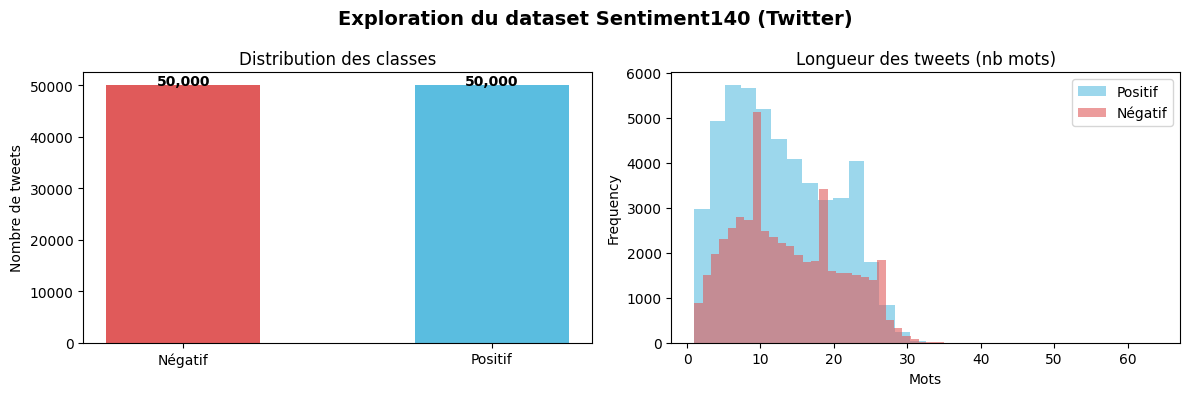


 Longueur moyenne : 13 mots
   Min : 1 | Max : 64


In [87]:
# Cellule Exploration — Sentiment140

import matplotlib.pyplot as plt

# Garder uniquement les colonnes utiles
df = df[["text", "sentiment"]]

# Valeurs manquantes
print(" Valeurs manquantes :")
print(df.isnull().sum())

# Distribution
print("\n Distribution :")
print(df["sentiment"].value_counts().rename({0: 'Négatif', 1: 'Positif'}))

# Longueur
df['nb_mots'] = df['text'].str.split().str.len()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Exploration du dataset Sentiment140 (Twitter)', fontsize=14, fontweight='bold')

counts = df['sentiment'].value_counts().rename({0: 'Négatif', 1: 'Positif'})
axes[0].bar(counts.index, counts.values, color=['#E05A5A', '#5ABDE0'], width=0.5)
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel("Nombre de tweets")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha='center', fontweight='bold')

df[df['sentiment']==1]['nb_mots'].plot(kind='hist', bins=30,
    alpha=0.6, color='#5ABDE0', label='Positif', ax=axes[1])
df[df['sentiment']==0]['nb_mots'].plot(kind='hist', bins=30,
    alpha=0.6, color='#E05A5A', label='Négatif', ax=axes[1])
axes[1].set_title('Longueur des tweets (nb mots)')
axes[1].set_xlabel('Mots')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\n Longueur moyenne : {df['nb_mots'].mean():.0f} mots")
print(f"   Min : {df['nb_mots'].min()} | Max : {df['nb_mots'].max()}")

In [88]:
# Cellule 6 — Fonction de nettoyage du texte

# Configuration
STOPWORDS = set(stopwords.words('english'))
# On garde les négations — elles portent du sentiment !
STOPWORDS -= {'no','not','nor','never','nothing','wasn','isn','won'}
lemmatizer = WordNetLemmatizer()

def nettoyer_texte(texte):
    """Nettoie un avis en 6 étapes."""
    # Étape 1 : minuscules
    texte = str(texte).lower()
    # Étape 2 : suppression des balises HTML (<br />, etc.)
    texte = re.sub(r'<[^>]+>', ' ', texte)
    # Étape 3 : suppression ponctuation et chiffres
    texte = re.sub(r'[^a-zs]', ' ', texte)
    # Étape 4 : suppression espaces multiples
    texte = re.sub(r's+', ' ', texte).strip()
    # Étape 5 : tokenisation + suppression stopwords
    tokens = [t for t in texte.split() if t not in STOPWORDS and len(t) > 2]
    # Étape 6 : lemmatisation (runs → run, better → good)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Test visuel avant / après
exemple = df['text'].iloc[0]
print("AVANT :", exemple[:200])
print("\nAPRÈS :", nettoyer_texte(exemple)[:200])

AVANT : @xnausikaax oh no! where did u order from? that's horrible 

APRÈS : xnau ikaax order horrible


In [89]:
# Cellule 7 — Application du preprocessing sur tout le dataset

print(" Nettoyage en cours (1-2 min sur Colab)...")
t0 = time.time()

df['clean_review'] = df['text'].apply(nettoyer_texte)

elapsed = time.time() - t0
print(f"Terminé en {elapsed:.1f}s")

# Vérification : longueur avant / après
df['mots_avant'] = df['text'].str.split().str.len()
df['mots_apres'] = df['clean_review'].str.split().str.len()

print(f"\n Réduction moyenne : {df['mots_avant'].mean():.0f} → {df['mots_apres'].mean():.0f} mots")
print(f"   (soit -{(1 - df['mots_apres'].mean()/df['mots_avant'].mean())*100:.0f}% de mots)")

# Aperçu
df[['text', 'clean_review', 'sentiment']].head(2)

 Nettoyage en cours (1-2 min sur Colab)...
Terminé en 4.6s

 Réduction moyenne : 13 → 7 mots
   (soit -45% de mots)


,text,clean_review,sentiment
0,@xnausikaax oh no! where did u order from? tha...,xnau ikaax order horrible,0
1,A great hard training weekend is over. a coup...,great hard training weekend couple day let lot...,0
